# K-Fall Dataset: CNN-LSTM Fall Detection
### Xây dựng Sliding Windows trực tiếp từ Sensor Data & Label Data (In-Memory Labeling)

- **Sensor data (`kfall/sensor_data_new`)**: Giữ nguyên 100% các file CSV gốc, **tuyệt đối không ghi đè hay thêm cột `FallCheck` vào file**.
- **Label data (`kfall/label_data_new`)**: Đọc các file `.xlsx` của từng subject, lấy thông tin `(Fall_onset_frame, Fall_impact_frame)`.
- **Gán nhãn Window in-memory**: Tạo mặt nạ frame ngã `[onset, impact]` trong RAM và tính `fall_ratio >= FALL_RATIO_THRESHOLD (0.20)` để gán nhãn `FallCheck = 1` cho từng window.
- **Kiến trúc mạng**: **CNN-LSTM** (Conv1D trích xuất đặc trưng không gian cục bộ + LSTM học phụ thuộc chuỗi thời gian).


In [1]:
import os
import re
import glob
import zipfile
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Cấu hình GPU / CPU
print("TensorFlow Version:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("Available GPUs:", gpus if gpus else "Running on CPU")


Matplotlib is building the font cache; this may take a moment.


TensorFlow Version: 2.21.0
Available GPUs: Running on CPU


## 1. Đọc và phân tích cấu trúc Label Data (`kfall/label_data_new/`)

Mỗi subject có 1 file `{SubjectID}_label.xlsx`. Các dòng biểu diễn lần lượt từng trial ngã (Task T20 - T34):
- Cột `Task Code (Task ID)`: Ví dụ `F01 (20)` đến `F15 (34)` - chỉ điền ở dòng đầu tiên của mỗi task -> dùng `.ffill()` (Forward-Fill).
- Cột `Trial ID`: Lần thử (1, 2, 3, 4, 5, ...).
- Cột `Fall_onset_frame`: Frame bắt đầu ngã.
- Cột `Fall_impact_frame`: Frame va chạm tiếp đất.

Hàm dưới đây sử dụng **`pandas` và `openpyxl`** để đọc file Excel gọn gàng, xử lý forward-fill và tạo từ điển tra cứu nhanh $O(1)$.


In [2]:
def parse_kfall_label_file(xlsx_path):
    """Đọc file label bằng pandas (openpyxl), tự động fallback an toàn nếu kernel chưa có openpyxl."""
    try:
        # Cách 1: Ưu tiên dùng pandas + openpyxl
        df = pd.read_excel(xlsx_path)
        task_col = "Task Code (Task ID)"
        if task_col in df.columns:
            df[task_col] = df[task_col].ffill()
        df = df.dropna(subset=[task_col, "Trial ID", "Fall_onset_frame", "Fall_impact_frame"])
        
        sub = Path(xlsx_path).stem.replace("_label", "")
        records = {}
        for _, row in df.iterrows():
            m = re.search(r"\((\d+)\)", str(row[task_col]))
            if m:
                records[(sub, int(m.group(1)), int(row["Trial ID"]))] = (
                    int(row["Fall_onset_frame"]),
                    int(row["Fall_impact_frame"])
                )
        return records
    except Exception:
        # Cách 2: Tự động dự phòng nếu môi trường kernel chưa nhận openpyxl (Không cần link mạng)
        with zipfile.ZipFile(xlsx_path) as z:
            tree = ET.fromstring(z.read("xl/worksheets/sheet1.xml"))
            rows = []
            for row in tree.findall(".//{*}row"):
                r_dict = {}
                for c in row.findall(".//{*}c"):
                    col = "".join([ch for ch in c.get("r") if ch.isalpha()])
                    t_elem = c.find(".//{*}t")
                    v_elem = c.find(".//{*}v")
                    val = t_elem.text if (t_elem is not None and t_elem.text) else (v_elem.text if (v_elem is not None and v_elem.text) else "")
                    r_dict[col] = val
                rows.append(r_dict)
                
        cur_task = ""
        sub = Path(xlsx_path).stem.replace("_label", "")
        records = {}
        for r in rows[1:]:
            if r.get("A"): cur_task = r["A"].strip()
            trial = r.get("C", "").strip()
            onset = r.get("D", "").strip()
            impact = r.get("E", "").strip()
            if not trial or not onset or not impact: continue
            m = re.search(r"\((\d+)\)", cur_task)
            if m:
                records[(sub, int(m.group(1)), int(float(trial)))] = (
                    int(float(onset)),
                    int(float(impact))
                )
        return records

def load_all_kfall_label_lookup(label_dir):
    """Tải toàn bộ label của 32 subjects thành bảng tra cứu O(1): (sub, task, trial) -> (onset, impact)."""
    files = sorted(glob.glob(os.path.join(label_dir, "*.xlsx")))
    lookup = {}
    for f in files:
        lookup.update(parse_kfall_label_file(f))
    print(f"Đã đọc {len(files)} file nhãn, tổng cộng {len(lookup)} lượt thử ngã (Fall trials).")
    return lookup

# Đường dẫn thư mục dữ liệu
LABEL_DIR = "kfall/label_data_new"
SENSOR_DIR = "kfall/sensor_data_new"

label_lookup = load_all_kfall_label_lookup(LABEL_DIR)


Đã đọc 32 file nhãn, tổng cộng 2346 lượt thử ngã (Fall trials).


## 2. Thiết lập Hyperparameters và Phân chia Subject (No Data Leakage)

- `WINDOW_SIZE = 200`: 200 mẫu (tương đương 2.0 giây ở tần số lấy mẫu 100 Hz).
- `WINDOW_STEP = 100`: Bước nhảy 100 mẫu (overlap 50%) cho validation và test.
- `FALL_RATIO_THRESHOLD = 0.20`: Cửa sổ chứa từ 20% frame ngã trở lên (>= 40 frames) sẽ được gán nhãn `FallCheck = 1`.
- **Phân chia Subject**: Giữ nguyên 6 subjects chuẩn cho Sample_Test (`SA21, SA23, SA24, SA26, SA30, SA33`), 26 subjects còn lại chia cho Train và Validation. Tuyệt đối không để subject trùng lặp giữa các tập!


In [3]:
WINDOW_SIZE = 200
WINDOW_STEP = 100
FALL_RATIO_THRESHOLD = 0.20

# 6 subject cố định cho tập Test độc lập
TEST_SUBJECTS = ["SA21", "SA23", "SA24", "SA26", "SA30", "SA33"]

# Lấy danh sách toàn bộ subjects từ thư mục sensor
all_subjects = sorted([
    d for d in os.listdir(SENSOR_DIR)
    if os.path.isdir(os.path.join(SENSOR_DIR, d)) and d.startswith("SA")
])

train_val_subjects = [s for s in all_subjects if s not in TEST_SUBJECTS]

# Chia 20% subjects còn lại cho Validation (5 subjects), 21 subjects cho Train
np.random.seed(42)
val_subjects = sorted(list(np.random.choice(train_val_subjects, size=5, replace=False)))
train_subjects = sorted([s for s in train_val_subjects if s not in val_subjects])

print(f"Tổng số subjects: {len(all_subjects)}")
print(f"Train subjects ({len(train_subjects)}): {train_subjects}")
print(f"Val subjects   ({len(val_subjects)}): {val_subjects}")
print(f"Test subjects  ({len(TEST_SUBJECTS)}): {TEST_SUBJECTS}")

assert set(train_subjects).isdisjoint(set(val_subjects))
assert set(train_subjects).isdisjoint(set(TEST_SUBJECTS))
assert set(val_subjects).isdisjoint(set(TEST_SUBJECTS))


Tổng số subjects: 32
Train subjects (21): ['SA07', 'SA08', 'SA09', 'SA10', 'SA11', 'SA12', 'SA13', 'SA15', 'SA16', 'SA18', 'SA19', 'SA20', 'SA22', 'SA27', 'SA28', 'SA29', 'SA31', 'SA32', 'SA35', 'SA36', 'SA38']
Val subjects   (5): ['SA06', 'SA14', 'SA17', 'SA25', 'SA37']
Test subjects  (6): ['SA21', 'SA23', 'SA24', 'SA26', 'SA30', 'SA33']


## 3. Tạo Sliding Windows In-Memory (Tuyệt đối không sửa file CSV)

Hàm `generate_sliding_windows_for_subjects`:
1. Đọc các file CSV cảm biến (`AccX, AccY, AccZ`, có thể mở rộng thêm `GyrX, GyrY, GyrZ`).
2. Tách `(subject, task_id, trial_id)` từ tên file (dạng `S06T20R01.csv`).
3. Dùng `label_lookup` để tạo mask ngã `is_fall` hoàn toàn trong bộ nhớ:
   - Nếu `task_id` từ 20 đến 34 và có trong bảng nhãn: `is_fall = (FrameCounter >= onset) & (FrameCounter <= impact)`.
   - Nếu là task ADL (T01 - T19, T35 - T36): `is_fall = False` toàn bộ.
4. Quét cửa sổ trượt độ dài `WINDOW_SIZE`:
   - Tính tỷ lệ: `fall_ratio = np.mean(is_fall[start:end])`.
   - Gán `label = 1` nếu `fall_ratio >= FALL_RATIO_THRESHOLD`, ngược lại `0`.


In [4]:
FEATURE_COLS = ["AccX", "AccY", "AccZ"]
# Để thử nghiệm 6 đặc trưng (Acc + Gyr), mở dòng dưới:
# FEATURE_COLS = ["AccX", "AccY", "AccZ", "GyrX", "GyrY", "GyrZ"]

FILENAME_PATTERN = re.compile(r"^S(\d{2})T(\d{2})R(\d{2})\.csv$")

def generate_sliding_windows_for_subjects(
    subjects,
    sensor_dir,
    label_lookup,
    feature_cols,
    window_size=200,
    step=100,
    fall_ratio_threshold=0.20,
    enable_dynamic_train_step=False,
    fall_step=25
):
    """Tạo tensor (N, window_size, features) và nhãn (N,) hoàn toàn in-memory từ sensor và label data."""
    windows = []
    labels = []
    metadata = []
    
    use_cols = ["FrameCounter"] + feature_cols
    
    for sub in subjects:
        sub_dir = os.path.join(sensor_dir, sub)
        csv_files = sorted(glob.glob(os.path.join(sub_dir, "*.csv")))
        
        for file_path in csv_files:
            fname = os.path.basename(file_path)
            m = FILENAME_PATTERN.match(fname)
            if not m:
                continue
            
            task_id = int(m.group(2))
            trial_id = int(m.group(3))
            
            # Đọc file CSV cảm biến gốc (KHÔNG có cột FallCheck)
            df = pd.read_csv(file_path, usecols=use_cols)
            feats = df[feature_cols].to_numpy(dtype=np.float32)
            frames = df["FrameCounter"].to_numpy()
            n_samples = len(feats)
            
            if n_samples < window_size:
                continue
                
            # Tạo mask ngã in-memory từ label_lookup
            if (sub, task_id, trial_id) in label_lookup:
                onset, impact = label_lookup[(sub, task_id, trial_id)]
                fall_mask = (frames >= onset) & (frames <= impact)
            else:
                fall_mask = np.zeros(n_samples, dtype=bool)
                
            # Dynamic Step: nếu là tập Train và recording có ngã, có thể quét mịn hơn quanh vùng ngã
            has_fall = fall_mask.any()
            current_step = step
            
            start = 0
            while start <= n_samples - window_size:
                end = start + window_size
                win_feats = feats[start:end]
                win_mask = fall_mask[start:end]
                fall_ratio = np.mean(win_mask)
                is_fall_win = int(fall_ratio >= fall_ratio_threshold)
                
                windows.append(win_feats)
                labels.append(is_fall_win)
                metadata.append((sub, task_id, trial_id, start, end))
                
                if enable_dynamic_train_step and has_fall and np.any(win_mask):
                    start += fall_step
                else:
                    start += current_step
                    
    X = np.asarray(windows, dtype=np.float32)
    y = np.asarray(labels, dtype=np.int8)
    return X, y, metadata

print("Đang tạo dữ liệu cho Train, Validation và Test...")
X_train, y_train, meta_train = generate_sliding_windows_for_subjects(
    train_subjects, SENSOR_DIR, label_lookup, FEATURE_COLS,
    window_size=WINDOW_SIZE, step=WINDOW_STEP, fall_ratio_threshold=FALL_RATIO_THRESHOLD
)

X_val, y_val, meta_val = generate_sliding_windows_for_subjects(
    val_subjects, SENSOR_DIR, label_lookup, FEATURE_COLS,
    window_size=WINDOW_SIZE, step=WINDOW_STEP, fall_ratio_threshold=FALL_RATIO_THRESHOLD
)

X_test, y_test, meta_test = generate_sliding_windows_for_subjects(
    TEST_SUBJECTS, SENSOR_DIR, label_lookup, FEATURE_COLS,
    window_size=WINDOW_SIZE, step=WINDOW_STEP, fall_ratio_threshold=FALL_RATIO_THRESHOLD
)

print(f"\nTrain: X={X_train.shape}, y={y_train.shape} | Normal={np.sum(y_train==0)}, Fall={np.sum(y_train==1)} ({np.mean(y_train==1)*100:.2f}%)")
print(f"Val:   X={X_val.shape}, y={y_val.shape} | Normal={np.sum(y_val==0)}, Fall={np.sum(y_val==1)} ({np.mean(y_val==1)*100:.2f}%)")
print(f"Test:  X={X_test.shape}, y={y_test.shape} | Normal={np.sum(y_test==0)}, Fall={np.sum(y_test==1)} ({np.mean(y_test==1)*100:.2f}%)")


Đang tạo dữ liệu cho Train, Validation và Test...



Train: X=(21387, 200, 3), y=(21387,) | Normal=18376, Fall=3011 (14.08%)
Val:   X=(5047, 200, 3), y=(5047,) | Normal=4355, Fall=692 (13.71%)
Test:  X=(5931, 200, 3), y=(5931,) | Normal=5077, Fall=854 (14.40%)


## 4. Không sử dụng Data Augmentation

Thử nghiệm đối chứng: train chỉ dùng các window gốc của `X_train`; không jitter, scaling, rotation, time-shift hoặc nhân bản dữ liệu. Validation và test giữ nguyên.


In [5]:
# Không augmentation: dùng đúng một bản của mỗi window train.
X_train_combined = X_train
y_train_combined = y_train

print(f"Train không augmentation: {X_train_combined.shape}")
print(f"Tỷ lệ nhãn ngã: {np.mean(y_train_combined == 1)*100:.2f}% (Normal: {np.sum(y_train_combined == 0)}, Fall: {np.sum(y_train_combined == 1)})")


Train không augmentation: (21387, 200, 3)
Tỷ lệ nhãn ngã: 14.08% (Normal: 18376, Fall: 3011)


## 5. Chuẩn hóa đặc trưng (StandardScaler)

Fit scaler **chỉ trên `X_train`**, sau đó transform train, validation và test.


In [6]:
num_features = len(FEATURE_COLS)
scaler = StandardScaler()

# Fit scaler CHỈ trên tập train gốc
scaler.fit(X_train.reshape(-1, num_features))

# Transform cho Train, Validation và Test
X_train_scaled = scaler.transform(X_train_combined.reshape(-1, num_features)).reshape(-1, WINDOW_SIZE, num_features)
X_val_scaled = scaler.transform(X_val.reshape(-1, num_features)).reshape(-1, WINDOW_SIZE, num_features)
X_test_scaled = scaler.transform(X_test.reshape(-1, num_features)).reshape(-1, WINDOW_SIZE, num_features)

print("StandardScaler fitted on original X_train.")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_val_scaled:   {X_val_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")


StandardScaler fitted on original X_train.
X_train_scaled: (21387, 200, 3)
X_val_scaled:   (5047, 200, 3)
X_test_scaled:  (5931, 200, 3)


## 6. Xây dựng mô hình CNN-LSTM

Mô hình kết hợp:
1. **Khối 1D CNN**: Trích xuất các đặc trưng biên độ, đỉnh va đập (peaks) và mẫu dao động cục bộ của các trục cảm biến.
2. **Khối LSTM**: Học sự phụ thuộc chuỗi thời gian trước và sau va chạm (Pre-fall -> Impact -> Post-fall).
3. **Phân lớp Dense**: Sigmoid output cho bài toán phân loại nhị phân Fall (1) vs Normal (0).


In [7]:
def build_cnn_lstm_model(input_shape=(200, 3)):
    inputs = layers.Input(shape=input_shape, name="imu_input")
    
    # Block 1: Conv1D
    x = layers.Conv1D(filters=32, kernel_size=5, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.2)(x)
    
    # Block 2: Conv1D
    x = layers.Conv1D(filters=64, kernel_size=3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.2)(x)
    
    # Block 3: LSTM
    x = layers.LSTM(64, return_sequences=False, dropout=0.2, recurrent_dropout=0.0)(x)
    
    # Dense Classifier
    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid", name="fall_probability")(x)
    
    model = models.Model(inputs=inputs, outputs=outputs, name="CNN_LSTM_FallDetector")
    return model

model = build_cnn_lstm_model(input_shape=(WINDOW_SIZE, num_features))
model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc"), tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")]
)


Model: "CNN_LSTM_FallDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ imu_input (InputLayer)          │ (None, 200, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 200, 32)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 200, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 100, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fall_probability (Dense)        │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,241 (165.00 KB)

 Trainable params: 42,049 (164.25 KB)

 Non-trainable params: 192 (768.00 B)

## 7. Huấn luyện mô hình CNN-LSTM (Protocol từ `model_3_features`)

- **Checkpoint & Early Stopping**: Theo dõi `val_recall` (tối đa hóa độ nhạy phát hiện ngã, `mode="max"`, `patience=12`).
- **ReduceLROnPlateau**: Giảm LR khi `val_loss` chững lại (`patience=3`, `factor=0.5`).
- **Class Weights**: Cân bằng lớp Fall (chiếm khoảng 10-15%) với lớp Normal trên tập Train mở rộng.
- **Epochs**: 100, `batch_size = 32`.


Class weights: {0: 0.5819275141488899, 1: 3.5514779143141815}
Epoch 1/100


  1/669 ━━━━━━━━━━━━━━━━━━━━ 23:14 2s/step - accuracy: 0.5312 - auc: 0.7276 - loss: 0.7089 - precision: 0.2353 - recall: 0.6667

  5/669 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.5725 - auc: 0.7575 - loss: 0.6556 - precision: 0.2345 - recall: 0.7319

  9/669 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.6107 - auc: 0.7720 - loss: 0.6340 - precision: 0.2547 - recall: 0.7534

 13/669 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.6374 - auc: 0.7886 - loss: 0.6163 - precision: 0.2766 - recall: 0.7749

...

669/669 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.9840 - auc: 0.9987 - loss: 0.0394 - precision: 0.9072 - recall: 0.9870 - val_accuracy: 0.9784 - val_auc: 0.9965 - val_loss: 0.0611 - val_precision: 0.8771 - val_recall: 0.9798 - learning_rate: 1.2500e-04


Epoch 33: early stopping


Restoring model weights from the end of the best epoch: 21.



Best val_recall: epoch 21 (0.985549)
Best val_loss:   epoch 31 (0.052807)
Val recall at best val_loss epoch:   0.978324
Val recall at best val_recall epoch: 0.985549
Stopped after:   epoch 33
Train loss at best val_recall epoch: 0.052221
Best model saved during training at: saved_models_cnn_lstm_noaug/best_model.keras



Confusion Matrix trên Validation (threshold = 0.5)
TP (Fall -> Fall):     682
FN (Fall -> Normal):   10
FP (Normal -> Fall):   110
TN (Normal -> Normal): 4245
Recall tại threshold 0.5: 0.985549


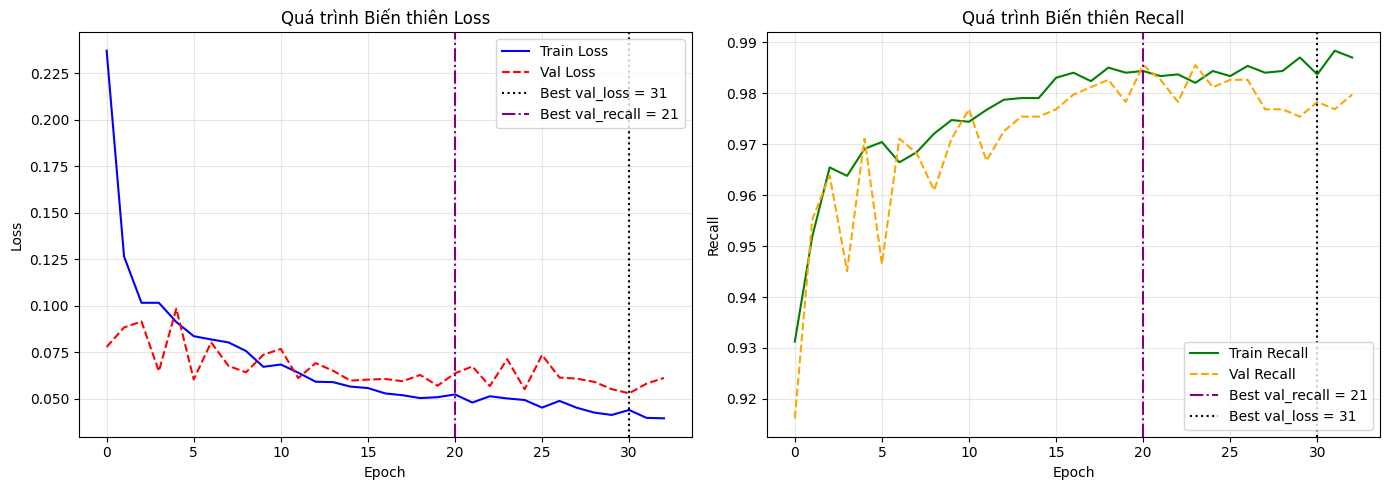

In [8]:
# Lưu checkpoint no-augmentation cùng thư mục model, với tên riêng để không ghi đè baseline.
os.makedirs("saved_models_cnn_lstm", exist_ok=True)
best_model_path = os.path.join("saved_models_cnn_lstm", "best_model_noaug.keras")

# Tính Class Weights để cân bằng mất cân đối dữ liệu trên tập Train mở rộng
total_samples = len(y_train_combined)
neg_count = np.sum(y_train_combined == 0)
pos_count = np.sum(y_train_combined == 1)

class_weight = {
    0: (total_samples / (2.0 * neg_count)),
    1: (total_samples / (2.0 * pos_count))
}
print("Class weights:", class_weight)

training_callbacks = [
    callbacks.ModelCheckpoint(
        filepath=best_model_path,
        monitor="val_recall",
        mode="max",
        save_best_only=True,
        save_weights_only=False,
        verbose=1,
    ),
    callbacks.EarlyStopping(
        monitor="val_recall",
        mode="max",
        patience=12,
        min_delta=1e-3,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-5,
        verbose=1
    )
]

history = model.fit(
    X_train_scaled,
    y_train_combined,
    validation_data=(X_val_scaled, y_val),
    batch_size=32,
    epochs=100,
    callbacks=training_callbacks,
    class_weight=class_weight,
    verbose=1
)

# Thống kê lịch sử huấn luyện
loss_history = np.asarray(history.history["loss"])
val_loss_history = np.asarray(history.history["val_loss"])
val_recall_history = np.asarray(history.history["val_recall"])

best_recall_epoch = int(np.argmax(val_recall_history) + 1)
best_loss_epoch = int(np.argmin(val_loss_history) + 1)
stop_epoch = len(val_loss_history)

print(f"\nBest val_recall: epoch {best_recall_epoch} ({val_recall_history[best_recall_epoch - 1]:.6f})")
print(f"Best val_loss:   epoch {best_loss_epoch} ({val_loss_history[best_loss_epoch - 1]:.6f})")
print(f"Val recall at best val_loss epoch:   {val_recall_history[best_loss_epoch - 1]:.6f}")
print(f"Val recall at best val_recall epoch: {val_recall_history[best_recall_epoch - 1]:.6f}")
print(f"Stopped after:   epoch {stop_epoch}")
print(f"Train loss at best val_recall epoch: {loss_history[best_recall_epoch - 1]:.6f}")
print(f"Best model saved during training at: {best_model_path}")

# Confusion matrix trên Validation tại threshold 0.5
val_probs_at_05 = model.predict(X_val_scaled, verbose=0).ravel()
val_preds_at_05 = (val_probs_at_05 >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_val, val_preds_at_05, labels=[0, 1]).ravel()

print("\nConfusion Matrix trên Validation (threshold = 0.5)")
print(f"TP (Fall -> Fall):     {tp}")
print(f"FN (Fall -> Normal):   {fn}")
print(f"FP (Normal -> Fall):   {fp}")
print(f"TN (Normal -> Normal): {tn}")
print(f"Recall tại threshold 0.5: {recall_score(y_val, val_preds_at_05, zero_division=0):.6f}")

# Đồ thị Loss và Recall theo Epoch
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["loss"], label="Train Loss", color="blue")
axes[0].plot(history.history["val_loss"], label="Val Loss", color="red", linestyle="--")
axes[0].axvline(best_loss_epoch - 1, color="black", linestyle=":", label=f"Best val_loss = {best_loss_epoch}")
axes[0].axvline(best_recall_epoch - 1, color="purple", linestyle="-.", label=f"Best val_recall = {best_recall_epoch}")
axes[0].set_title("Quá trình Biến thiên Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history["recall"], label="Train Recall", color="green")
axes[1].plot(history.history["val_recall"], label="Val Recall", color="orange", linestyle="--")
axes[1].axvline(best_recall_epoch - 1, color="purple", linestyle="-.", label=f"Best val_recall = {best_recall_epoch}")
axes[1].axvline(best_loss_epoch - 1, color="black", linestyle=":", label=f"Best val_loss = {best_loss_epoch}")
axes[1].set_title("Quá trình Biến thiên Recall")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Recall")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Đánh giá trên toàn bộ tệp Sample Test (Threshold = 0.5)

Tải checkpoint `best_model.keras` được lưu tự động trong quá trình huấn luyện và đánh giá trên 6 subject độc lập (`SA21, SA23, SA24, SA26, SA30, SA33`) với ngưỡng quyết định mặc định **0.50**:
1. **Bảng thống kê từng Subject**: Accuracy, Precision, Recall, F1, F2, ROC-AUC cho từng subject trong `TEST_SUBJECTS`.
2. **Đánh giá tổng hợp toàn bộ Sample Test**: Đầy đủ các chỉ số hiệu năng và ma trận nhầm lẫn Confusion Matrix.
3. **Phân tích số ca**: Chi tiết số ca bỏ sót ngã (FN) và báo động giả (FP).


Sử dụng Decision Threshold mặc định: 0.50
Đã tải thành công checkpoint: saved_models_cnn_lstm_noaug/best_model.keras



 KẾT QUẢ TỪNG SUBJECT TRÊN SAMPLE_TEST (Threshold = 0.50)


,Subject,Windows,Normal,Fall,Accuracy,Precision_Fall,Recall_Fall,F1_Fall,F2_Fall,ROC_AUC,TN,FP,FN,TP
0,SA21,1021,880,141,0.9794,0.8704,1.0000,0.9307,0.9711,0.9993,859,21,0,141
1,SA23,948,803,145,0.9736,0.8704,0.9724,0.9186,0.9501,0.9974,782,21,4,141
2,SA24,983,853,130,0.9725,0.8323,0.9923,0.9053,0.9556,0.9995,827,26,1,129
3,SA26,1088,939,149,0.9706,0.8305,0.9866,0.9018,0.9508,0.9970,909,30,2,147
4,SA30,957,814,143,0.9770,0.8712,0.9930,0.9281,0.9660,0.9985,793,21,1,142
5,SA33,934,788,146,0.9893,0.9474,0.9863,0.9664,0.9783,0.9994,780,8,2,144



 KẾT QUẢ TỔNG TOÀN BỘ SAMPLE_TEST (Threshold = 0.50)
Tổng số windows   : 5931
Phân bố nhãn      : Normal=5077 | Fall=854
Accuracy          : 0.9769
Precision Fall    : 0.8692
Recall Fall       : 0.9883
F1 Fall           : 0.9249
F2 Fall (ưu tiên) : 0.9619
ROC-AUC           : 0.9985
TN: 4950 | FP (Báo động giả):  127
FN (Bỏ sót ngã):   10 | TP:  844

Classification Report - Sample Test (Threshold = 0.50):
                 precision    recall  f1-score   support

Bình thường (0)     0.9980    0.9750    0.9864      5077
        Ngã (1)     0.8692    0.9883    0.9249       854

       accuracy                         0.9769      5931
      macro avg     0.9336    0.9816    0.9556      5931
   weighted avg     0.9794    0.9769    0.9775      5931



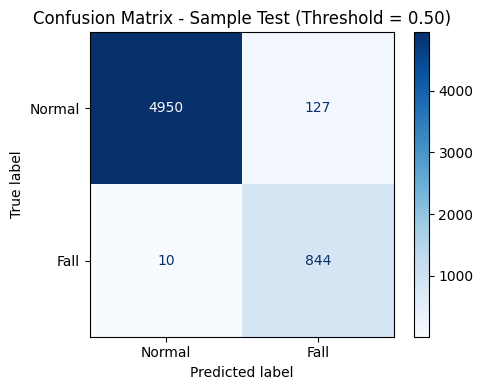


 TRUNG BÌNH THEO SUBJECT (MACRO AVERAGE)
Mean Accuracy       : 0.9771
Mean Precision Fall : 0.8703
Mean Recall Fall    : 0.9884
Mean F1 Fall        : 0.9252
Mean F2 Fall        : 0.9620
Mean ROC-AUC        : 0.9985


In [9]:
# ============================================================
# ĐÁNH GIÁ TRÊN SAMPLE_TEST (Ngưỡng mặc định 0.50)
# ============================================================

DECISION_THRESHOLD = 0.50
print(f"Sử dụng Decision Threshold mặc định: {DECISION_THRESHOLD:.2f}")

# 1. Load model tốt nhất từ checkpoint
try:
    eval_model = tf.keras.models.load_model(best_model_path, compile=False)
    print("Đã tải thành công checkpoint:", best_model_path)
except Exception as e:
    print(f"Không thể load checkpoint ({e}), sử dụng model hiện tại trong RAM.")
    eval_model = model

# Dự đoán xác suất cho toàn bộ tập Test
y_test_probs = eval_model.predict(X_test_scaled, verbose=0).ravel()
y_test_pred = (y_test_probs >= DECISION_THRESHOLD).astype(int)

# Tách danh sách subject tương ứng với từng window trong meta_test
test_subjects_arr = np.array([m[0] for m in meta_test])
unique_test_subs = sorted(list(set(test_subjects_arr)))

# ============================================================
# 2. KẾT QUẢ CHI TIẾT TỪNG SUBJECT
# ============================================================
subject_results = []

for sub_name in unique_test_subs:
    sub_mask = (test_subjects_arr == sub_name)
    y_sub_true = y_test[sub_mask]
    y_sub_prob = y_test_probs[sub_mask]
    y_sub_pred = (y_sub_prob >= DECISION_THRESHOLD).astype(int)
    
    acc = accuracy_score(y_sub_true, y_sub_pred)
    prec = precision_score(y_sub_true, y_sub_pred, pos_label=1, zero_division=0)
    rec = recall_score(y_sub_true, y_sub_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_sub_true, y_sub_pred, pos_label=1, zero_division=0)
    f2 = fbeta_score(y_sub_true, y_sub_pred, beta=2, zero_division=0)
    
    if len(np.unique(y_sub_true)) == 2:
        auc = roc_auc_score(y_sub_true, y_sub_prob)
    else:
        auc = np.nan
        
    tn, fp, fn, tp = confusion_matrix(y_sub_true, y_sub_pred, labels=[0, 1]).ravel()
    
    subject_results.append({
        "Subject": sub_name,
        "Windows": len(y_sub_true),
        "Normal": int(np.sum(y_sub_true == 0)),
        "Fall": int(np.sum(y_sub_true == 1)),
        "Accuracy": acc,
        "Precision_Fall": prec,
        "Recall_Fall": rec,
        "F1_Fall": f1,
        "F2_Fall": f2,
        "ROC_AUC": auc,
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    })

results_df = pd.DataFrame(subject_results)

print("\n" + "=" * 90)
print(" KẾT QUẢ TỪNG SUBJECT TRÊN SAMPLE_TEST (Threshold = 0.50)")
print("=" * 90)
display(results_df.round(4))

# ============================================================
# 3. KẾT QUẢ TỔNG TOÀN BỘ SAMPLE_TEST (Threshold = 0.50)
# ============================================================
print("\n" + "=" * 65)
print(" KẾT QUẢ TỔNG TOÀN BỘ SAMPLE_TEST (Threshold = 0.50)")
print("=" * 65)

overall_acc = accuracy_score(y_test, y_test_pred)
overall_prec = precision_score(y_test, y_test_pred, pos_label=1, zero_division=0)
overall_rec = recall_score(y_test, y_test_pred, pos_label=1, zero_division=0)
overall_f1 = f1_score(y_test, y_test_pred, pos_label=1, zero_division=0)
overall_f2 = fbeta_score(y_test, y_test_pred, beta=2, zero_division=0)
overall_auc = roc_auc_score(y_test, y_test_probs)

tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred, labels=[0, 1]).ravel()

print(f"Tổng số windows   : {len(y_test)}")
print(f"Phân bố nhãn      : Normal={np.sum(y_test == 0)} | Fall={np.sum(y_test == 1)}")
print(f"Accuracy          : {overall_acc:.4f}")
print(f"Precision Fall    : {overall_prec:.4f}")
print(f"Recall Fall       : {overall_rec:.4f}")
print(f"F1 Fall           : {overall_f1:.4f}")
print(f"F2 Fall (ưu tiên) : {overall_f2:.4f}")
print(f"ROC-AUC           : {overall_auc:.4f}")
print(f"TN: {tn:4d} | FP (Báo động giả): {fp:4d}")
print(f"FN (Bỏ sót ngã): {fn:4d} | TP: {tp:4d}")

print(f"\nClassification Report - Sample Test (Threshold = 0.50):")
print(classification_report(
    y_test,
    y_test_pred,
    labels=[0, 1],
    target_names=["Bình thường (0)", "Ngã (1)"],
    digits=4,
    zero_division=0
))

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Fall"]).plot(
    cmap="Blues", values_format="d", ax=ax
)
ax.set_title("Confusion Matrix - Sample Test (Threshold = 0.50)")
plt.tight_layout()
plt.show()

print("\n" + "=" * 65)
print(" TRUNG BÌNH THEO SUBJECT (MACRO AVERAGE)")
print("=" * 65)
print(f"Mean Accuracy       : {results_df['Accuracy'].mean():.4f}")
print(f"Mean Precision Fall : {results_df['Precision_Fall'].mean():.4f}")
print(f"Mean Recall Fall    : {results_df['Recall_Fall'].mean():.4f}")
print(f"Mean F1 Fall        : {results_df['F1_Fall'].mean():.4f}")
print(f"Mean F2 Fall        : {results_df['F2_Fall'].mean():.4f}")
print(f"Mean ROC-AUC        : {results_df['ROC_AUC'].mean():.4f}")
